In [7]:
import pandas as pd

# Define the file path
file_path = r'C:\Users\Dell\Pictures\Hustle\Datasets\customer_booking.csv'

# Load the CSV file into a pandas DataFrame using latin1 encoding
df = pd.read_csv(file_path, encoding='latin1')

# View the first 5 rows to see what the columns look like
print(df.head())

   num_passengers sales_channel  trip_type  purchase_lead  length_of_stay  \
0               2      Internet  RoundTrip            262              19   
1               1      Internet  RoundTrip            112              20   
2               2      Internet  RoundTrip            243              22   
3               1      Internet  RoundTrip             96              31   
4               2      Internet  RoundTrip             68              22   

   flight_hour flight_day   route booking_origin  wants_extra_baggage  \
0            7        Sat  AKLDEL    New Zealand                    1   
1            3        Sat  AKLDEL    New Zealand                    0   
2           17        Wed  AKLDEL          India                    1   
3            4        Sat  AKLDEL    New Zealand                    0   
4           15        Wed  AKLDEL          India                    1   

   wants_preferred_seat  wants_in_flight_meals  flight_duration  \
0                     0        

In [11]:
from sklearn.preprocessing import LabelEncoder

# Make a copy of the dataframe so we don't alter the raw data
df_model = df.copy()

# Find all columns containing text (using explicit 'str' to avoid the pandas 3.0 warning)
cat_cols = df_model.select_dtypes(
    include=['object', 'category', 'str']
).columns

# Convert each text category into numbers using LabelEncoder
for col in cat_cols:
  le = LabelEncoder()
  df_model[col] = le.fit_transform(df_model[col].astype(str))

# Separate features (X) from the target we want to predict (y)
X = df_model.drop(columns=['booking_complete'])
y = df_model['booking_complete']

print('Preprocessing complete! Features (X) shape:', X.shape)

Preprocessing complete! Features (X) shape: (50000, 13)


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

# 1. Split data into training (80%) and testing (20%) sets
# stratify=y ensures both sets have the same proportion of booked vs non-booked customers
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set shape: {X_train.shape}')
print(f'Testing set shape: {X_test.shape}')

# 2. Initialize the Random Forest Classifier
# class_weight='balanced' helps the model handle uneven booking classes effectively
rf_model = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced'
)

# 3. Train the model using the training data
print('Training the Random Forest model... Please wait a moment.')
rf_model.fit(X_train, y_train)
print('Model training complete!')

Training set shape: (40000, 13)
Testing set shape: (10000, 13)
Training the Random Forest model... Please wait a moment.
Model training complete!


--- Model Evaluation Metrics ---
Accuracy: 0.8309
ROC-AUC Score: 0.7812

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.92      0.90      8504
           1       0.42      0.34      0.37      1496

    accuracy                           0.83     10000
   macro avg       0.65      0.63      0.64     10000
weighted avg       0.82      0.83      0.82     10000



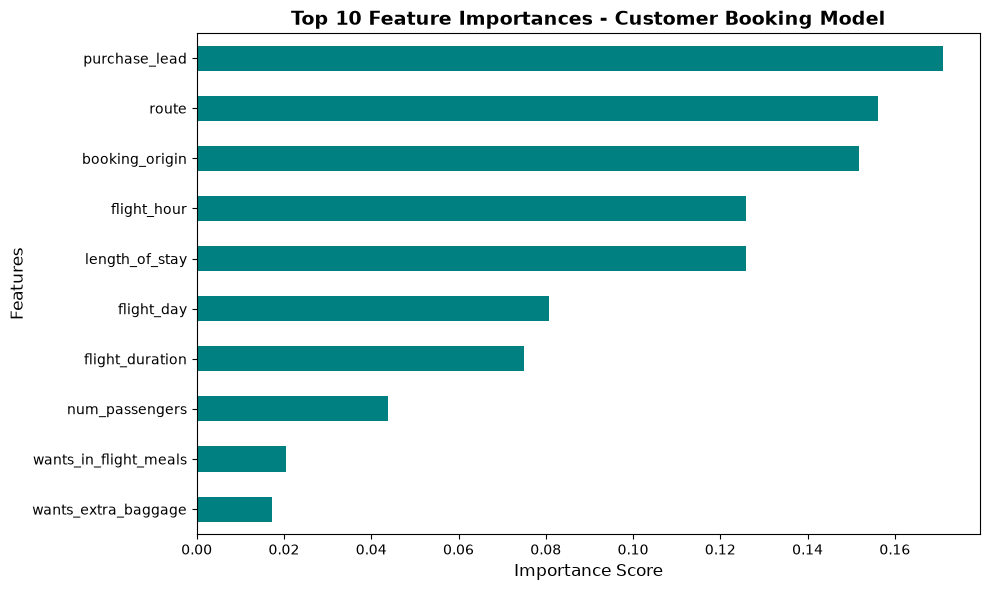


Feature importance plot generated and saved as "feature_importance.png"!


In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# 1. Evaluate Model Performance on the Test Set
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print('--- Model Evaluation Metrics ---')
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred))

# 2. Extract and Visualize Feature Importance
feature_importances = pd.Series(
    rf_model.feature_importances_, index=X.columns
).sort_values(ascending=False)

# Plot the top 10 most important features
plt.figure(figsize=(10, 6))
feature_importances.head(10).plot(kind='barh', color='teal')
plt.gca().invert_yaxis()  # Put the most important feature at the top
plt.title(
    'Top 10 Feature Importances - Customer Booking Model',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print(
    '\nFeature importance plot generated and saved as "feature_importance.png"!'
)

findfont: Failed to find font weight semibold for Arial, now using 700.


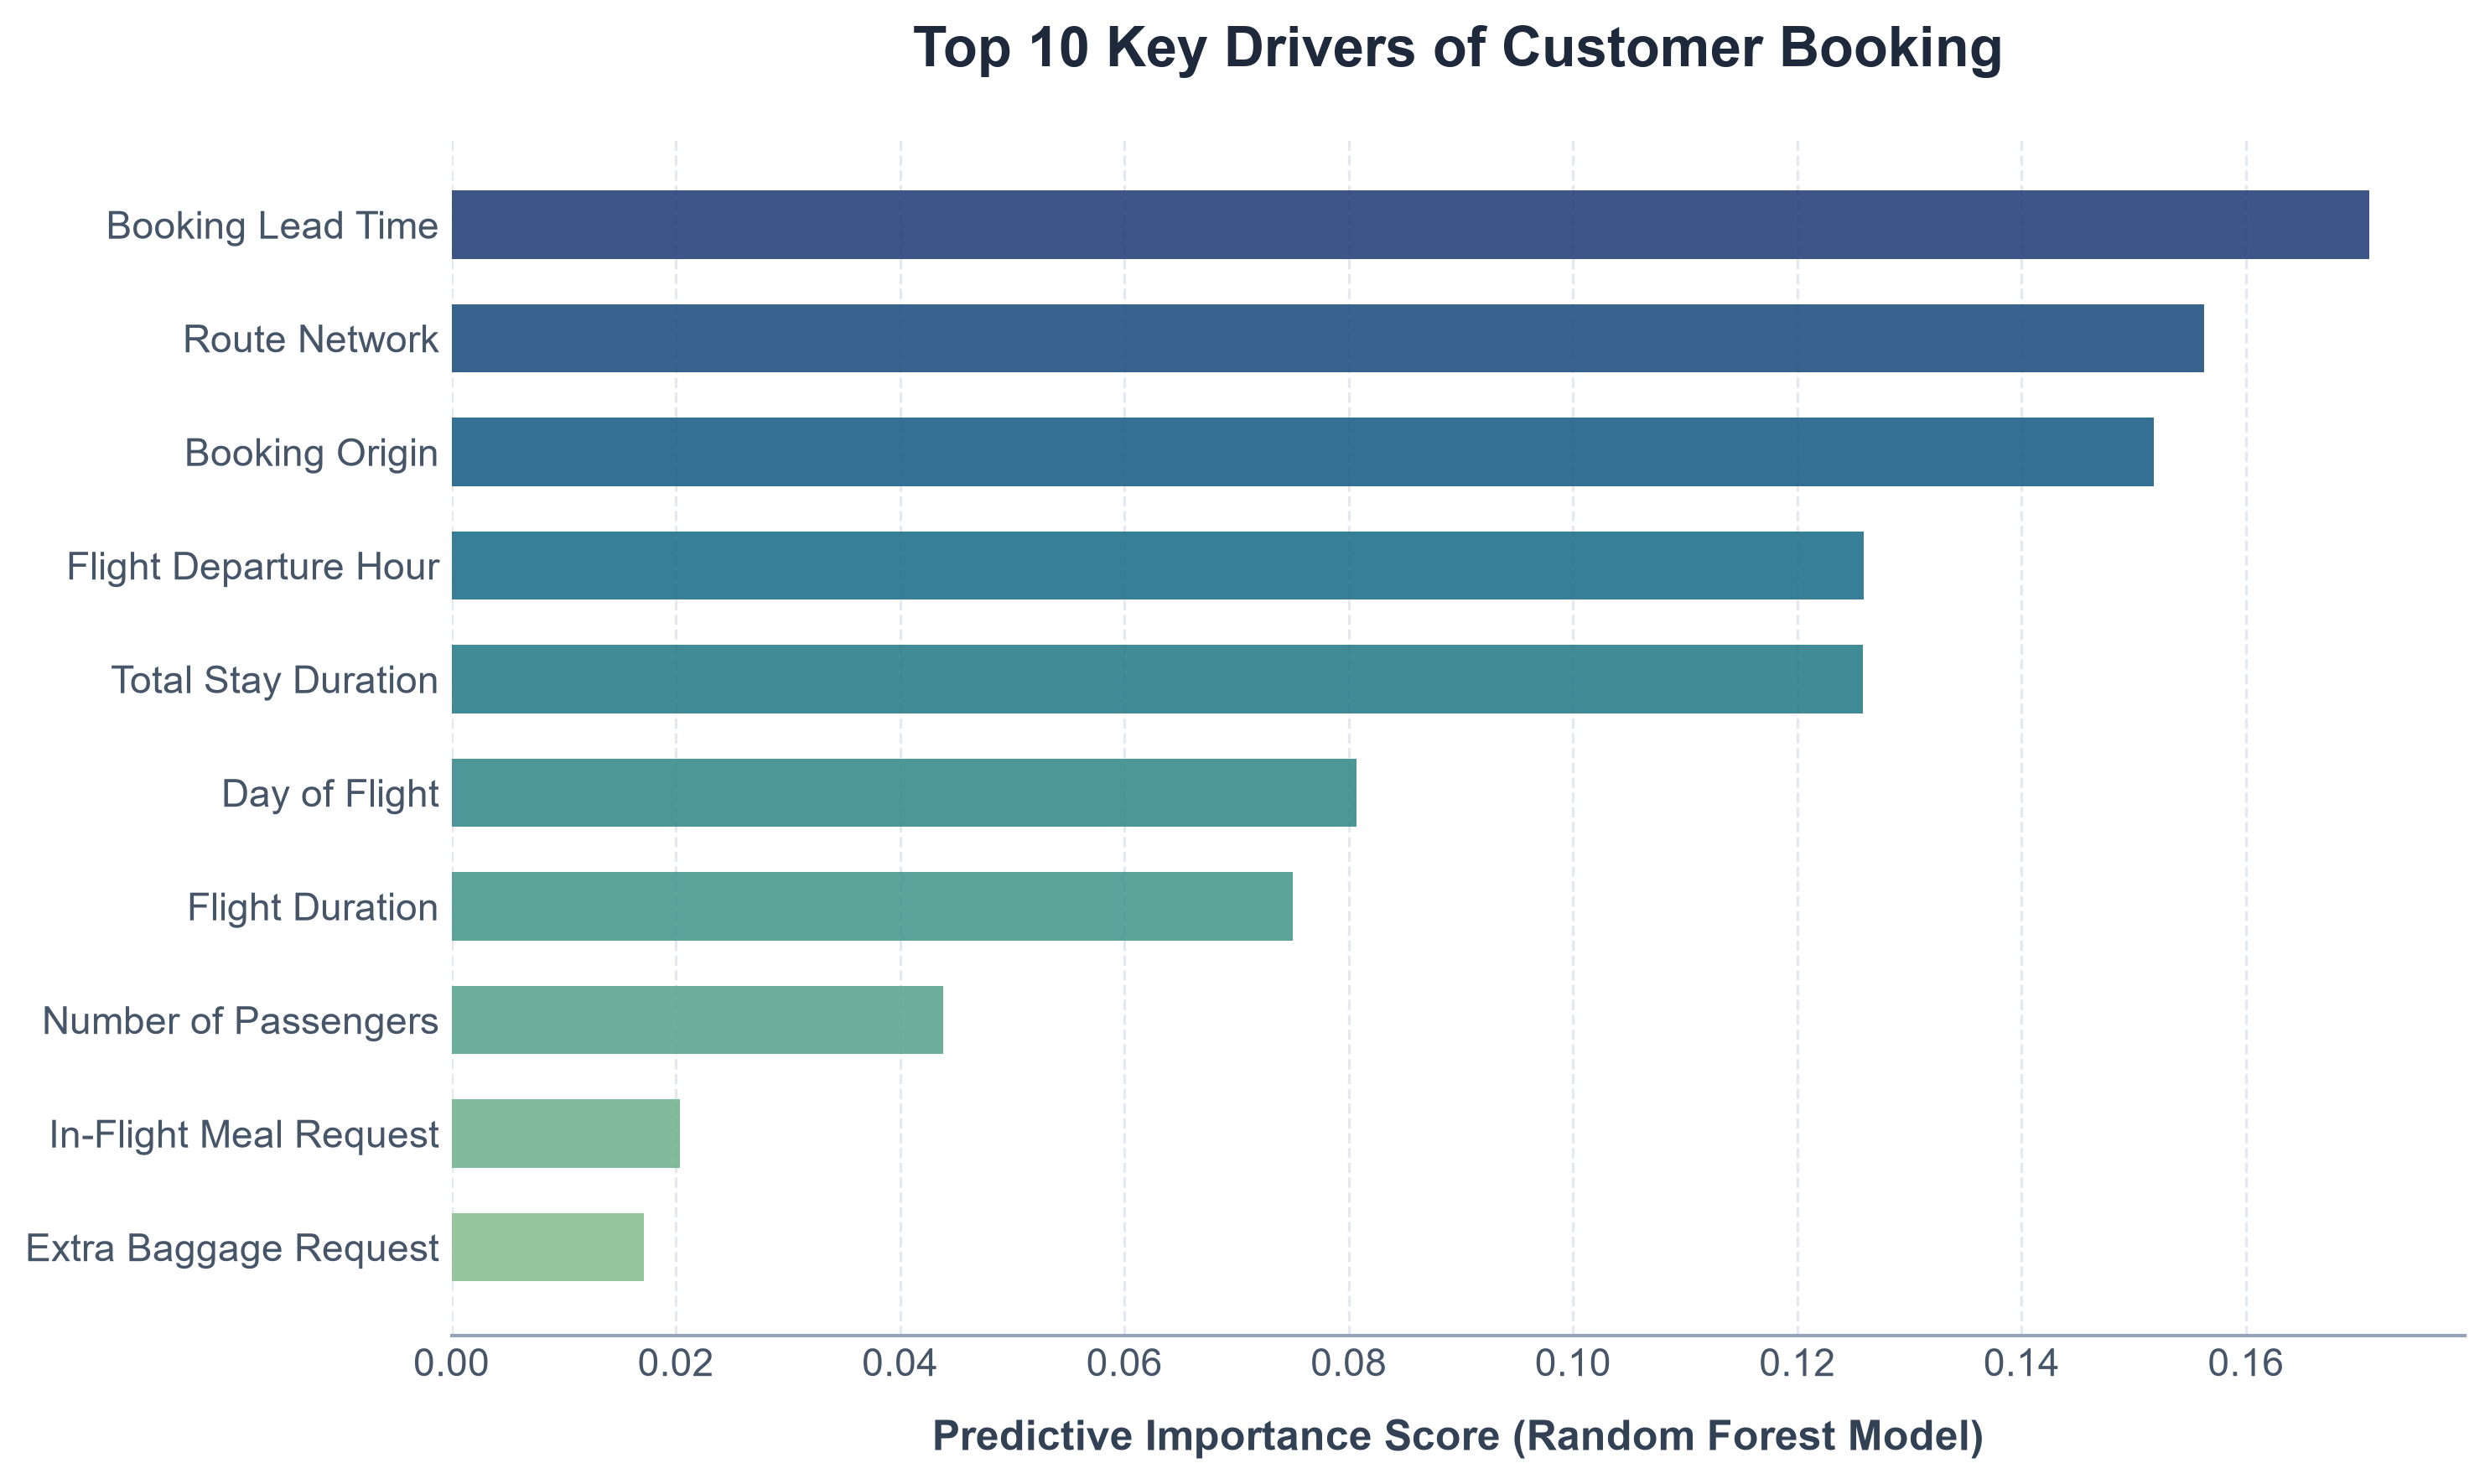

Professional chart generated and saved as "professional_feature_importance.png"!


In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Extract feature importances from your trained Random Forest model
feature_importances = pd.Series(
    rf_model.feature_importances_, index=X.columns
).sort_values(ascending=False)

# Optional: Map technical column names to clean, manager-friendly labels
rename_map = {
    'purchase_lead': 'Booking Lead Time',
    'route': 'Route Network',
    'booking_origin': 'Booking Origin',
    'flight_hour': 'Flight Departure Hour',
    'length_of_stay': 'Total Stay Duration',
    'flight_day': 'Day of Flight',
    'flight_duration': 'Flight Duration',
    'num_passengers': 'Number of Passengers',
    'wants_in_flight_meals': 'In-Flight Meal Request',
    'wants_extra_baggage': 'Extra Baggage Request',
}
# Apply map if columns exist, otherwise fallback to standard names
cleaned_importances = feature_importances.rename(index=rename_map).head(10)

# 2. Set up a clean figure with high resolution (dpi=300)
plt.style.use(
    'seaborn-v0_8-whitegrid'
    if 'seaborn-v0_8-whitegrid' in plt.style.available
    else 'default'
)
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# 3. Create horizontal bar chart with a professional color palette
colors = sns.color_palette('crest', n_colors=len(cleaned_importances))
bars = ax.barh(
    cleaned_importances.index[::-1],
    cleaned_importances.values[::-1],
    color=colors,
    height=0.6,
    alpha=0.9,
)

# 4. Typography & Title Polish
ax.set_title(
    'Top 10 Key Drivers of Customer Booking',
    fontsize=16,
    fontweight='bold',
    pad=20,
    color='#1e293b',
)
ax.set_xlabel(
    'Predictive Importance Score (Random Forest Model)',
    fontsize=12,
    fontweight='semibold',
    labelpad=10,
    color='#334155',
)

# Tick & Grid adjustments
ax.tick_params(axis='both', which='major', labelsize=11, colors='#475569')
ax.grid(axis='x', linestyle='--', alpha=0.5, color='#cbd5e1')
ax.grid(axis='y', visible=False)

# Remove unnecessary borders (spines) for a modern minimalist look
for spine in ['top', 'right', 'left']:
  ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#94a3b8')

plt.tight_layout()

# Save high-res version for your PowerPoint slide
plt.savefig(
    'professional_feature_importance.png', dpi=300, bbox_inches='tight'
)
plt.show()
print(
    'Professional chart generated and saved as'
    ' "professional_feature_importance.png"!'
)